<a href="https://colab.research.google.com/github/Fata-Haidar/244107020108-Pembelajaran-Mesin/blob/main/JS05/JS05_tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

**Load Data**

In [2]:
# Membaca dataset
df = pd.read_csv('voice.csv')

# Melihat data
display(df.head())

# Memeriksa data
print(df.shape)
print(df.isnull().sum())
print(df['label'].value_counts())

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


(3168, 21)
meanfreq    0
sd          0
median      0
Q25         0
Q75         0
IQR         0
skew        0
kurt        0
sp.ent      0
sfm         0
mode        0
centroid    0
meanfun     0
minfun      0
maxfun      0
meandom     0
mindom      0
maxdom      0
dfrange     0
modindx     0
label       0
dtype: int64
label
male      1584
female    1584
Name: count, dtype: int64


**Preprocessing**

In [3]:
# Menghapus data duplikat
df = df.drop_duplicates()

# Memisahkan fitur dan label
X = df.drop(columns=['label'])
y = df['label']

# Membagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Pada tahap preprocessing, saya menghapus data duplikat agar tidak ada data yang sama. Setelah itu, saya memisahkan fitur suara dan label male atau female. Selanjutnya, saya membagi data menjadi 80% untuk training dan 20% untuk testing agar model dapat dilatih dan diuji menggunakan data yang berbeda

**1. Membuat model klasifikasi kNN**

In [4]:
# Inisiasi model kNN
knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Melatih model
knn.fit(X_train, y_train)

# Melakukan prediksi
y_pred = knn.predict(X_test)

# Evaluasi model
akurasi = accuracy_score(y_test, y_pred)

print(f'Akurasi kNN: {akurasi:.4%}')
print(classification_report(y_test, y_pred))

Akurasi kNN: 97.6341%
              precision    recall  f1-score   support

      female       0.98      0.97      0.98       317
        male       0.97      0.98      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



Model menggunakan algoritma K-Nearest Neighbors (kNN) untuk mengklasifikasikan jenis suara menjadi male dan female. StandardScaler digunakan karena kNN menghitung jarak antardata, sehingga perbedaan skala antarfitur perlu diperhatikan.

**2. Percobaan untuk menentukan fitur optimal**

Pada tahap ini, digunakan metode SelectKBest untuk mencoba jumlah fitur dari 2 sampai 20. Setiap pilihan diuji menggunakan 5-fold cross-validation, bersamaan dengan beberapa nilai k.

In [5]:
# Membuat pipeline seleksi fitur dan kNN
model = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif)),
    ('knn', KNeighborsClassifier())
])

# Menentukan parameter percobaan
params = {
    'select__k': list(range(2, 21)),
    'knn__n_neighbors': list(range(1, 32, 2))
}

# Cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Percobaan kombinasi fitur dan nilai k
grid = GridSearchCV(
    model,
    params,
    cv=cv,
    scoring='accuracy',
    n_jobs=2
)

grid.fit(X_train, y_train)

# Mengambil fitur terbaik
fitur_terpilih = X.columns[
    grid.best_estimator_.named_steps['select'].get_support()
].tolist()

print("Jumlah fitur terbaik:", len(fitur_terpilih))
print("Fitur terpilih:", fitur_terpilih)
print(f"Akurasi validasi: {grid.best_score_:.4%}")

# Menguji model terbaik
prediksi_terbaik = grid.predict(X_test)

print(
    f"Akurasi testing: "
    f"{accuracy_score(y_test, prediksi_terbaik):.4%}"
)

Jumlah fitur terbaik: 7
Fitur terpilih: ['sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'centroid', 'meanfun']
Akurasi validasi: 98.1835%
Akurasi testing: 97.9495%


Berdasarkan percobaan, kombinasi tujuh fitur menghasilkan akurasi validasi silang sebesar 98,18%. Fitur yang terpilih adalah sd, Q25, IQR, sp.ent, sfm, centroid, dan meanfun

**3. Menentukan nilai k terbaik dan analisis grafik**

In [7]:
# Mengambil hasil percobaan dari nomor 2
hasil = pd.DataFrame(grid.cv_results_)

# Mengambil hasil percobaan berdasarkan fitur terpilih
grafik_k = hasil[
    hasil['param_select__k'].astype(int) == len(fitur_terpilih)
].copy()

# Mengurutkan nilai k
grafik_k['nilai_k'] = grafik_k[
    'param_knn__n_neighbors'
].astype(int)

grafik_k = grafik_k.sort_values('nilai_k')

# Menampilkan hasil
print(grafik_k[['nilai_k', 'mean_test_score']])

# Menampilkan nilai k terbaik
print(
    "Nilai k terbaik:",
    grid.best_params_['knn__n_neighbors']
)

     nilai_k  mean_test_score
5          1         0.978276
24         3         0.980650
43         5         0.981835
62         7         0.981045
81         9         0.981441
100       11         0.979465
119       13         0.976703
138       15         0.974729
157       17         0.973544
176       19         0.972358
195       21         0.969988
214       23         0.968408
233       25         0.967620
252       27         0.967226
271       29         0.966437
290       31         0.965252
Nilai k terbaik: 5


Tampilan Grafik

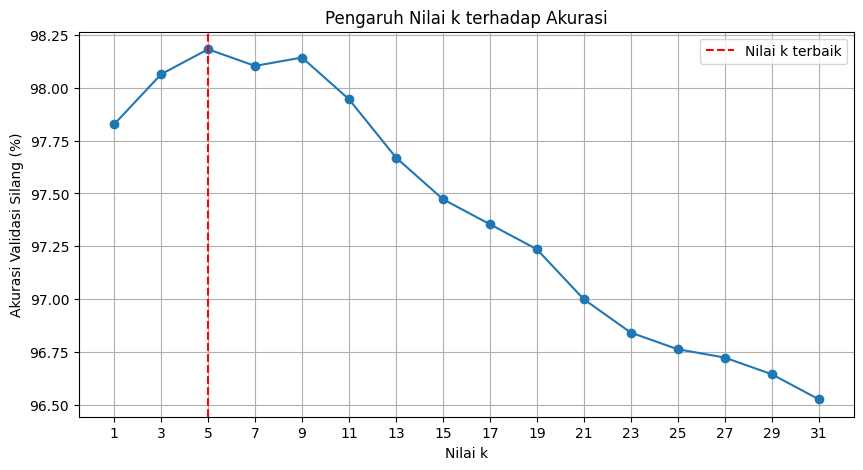

In [8]:
# Membuat grafik analisis nilai k
plt.figure(figsize=(10, 5))

plt.plot(
    grafik_k['nilai_k'],
    grafik_k['mean_test_score'] * 100,
    marker='o'
)

# Menandai nilai k terbaik
plt.axvline(
    grid.best_params_['knn__n_neighbors'],
    color='red',
    linestyle='--',
    label='Nilai k terbaik'
)

plt.title('Pengaruh Nilai k terhadap Akurasi')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi Validasi Silang (%)')
plt.xticks(range(1, 32, 2))
plt.grid(True)
plt.legend()
plt.show()